# Donor churn prediction — production pipeline (Lighthouse)

This notebook is the **dedicated churn modeling** artifact: leakage-aware labels, time-respecting validation, sklearn `Pipeline`s, and stakeholder-facing outputs (risk tiers, impact sketch, limitations).

**Data:** `ml-pipelines/lighthouse_csv_v7/supporters.csv`, `donations.csv`  
**Run from:** `ml-pipelines` (or set `DATA_DIR` below).

---

## Sections

1. [Problem Definition](#Problem-Definition)
2. [Data Preparation](#Data-Preparation)
3. [Feature Engineering](#Feature-Engineering)
4. [Modeling](#Modeling)
5. [Evaluation](#Evaluation)
6. [Business Insights](#Business-Insights)
7. [Limitations](#Limitations)

## Problem Definition

### Business goal

Identify donors who are **likely to stop giving** (no monetary or in-kind gift with positive PHP value) in the **near future**, so stewardship and marketing can **prioritize outreach** before lapse.

### Prediction target (binary churn)

- **Observation time** `as_of`: a date when we pretend to score donors.
- **Feature cutoff** `cutoff = as_of − prediction window`: all features use only donations with `donation_date ≤ cutoff`.
- **Label window** `(cutoff, as_of]`: we look only at this interval for outcomes.
- **`churn = 1`** if the supporter has **no donation with `value_php > 0`** in `(cutoff, as_of]`.
- **`churn = 0`** if they **do** have at least one such gift in that window.

We use **`PREDICTION_WINDOW_DAYS = 90`** so the model answers: *“Over the next 90 days after the feature snapshot, will this donor give (monetary/in-kind PHP)?”*

### Why class imbalance matters

Churn is often **rarer or skewed** vs active donors. Optimizing **accuracy** can hide a model that simply predicts “will give” for everyone. For retention, **recall on churn** (catching true lapsers) is usually more costly to miss than extra outreach to false alarms—so we report **precision, recall, F1, ROC-AUC**, tune decisions toward **recall**, and use **`class_weight='balanced'`**.

### Feature availability at prediction time

Every feature in the training matrix is computable **at cutoff** from historical donations and static supporter fields—**no future donation data** enters the feature vector.

## Data Preparation

In [14]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("lighthouse_csv_v7")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR.resolve()} — run from ml-pipelines or adjust DATA_DIR."
    )

PREDICTION_WINDOW_DAYS = 90
OBSERVATION_STEP_DAYS = 90
MIN_HISTORY_BEFORE_FIRST_OBS_DAYS = 180

supporters = pd.read_csv(
    DATA_DIR / "supporters.csv",
    parse_dates=["created_at", "first_donation_date"],
)
donations = pd.read_csv(
    DATA_DIR / "donations.csv",
    parse_dates=["donation_date"],
).copy()

DATA_AS_OF = donations["donation_date"].max()
print("Latest donation in extract:", DATA_AS_OF.date())
print("Supporters:", len(supporters), "| Donation rows:", len(donations))

Latest donation in extract: 2026-03-01
Supporters: 60 | Donation rows: 420


In [15]:
def donation_value_php(row: pd.Series) -> float:
    """Comparable PHP value for monetary + in-kind rows (time/skills excluded)."""
    if row["donation_type"] == "Monetary" and pd.notna(row["amount"]):
        return float(row["amount"])
    if row["donation_type"] == "InKind" and pd.notna(row["estimated_value"]):
        return float(row["estimated_value"])
    return 0.0


donations["value_php"] = donations.apply(donation_value_php, axis=1)
donations["has_positive_value"] = donations["value_php"] > 0

## Feature Engineering

All columns below are derived using **only** rows with `donation_date ≤ cutoff` (and supporter attributes that do not encode the future).

In [16]:
def _count_positive_gifts_between(
    d: pd.DataFrame, supporter_ids: pd.Series, start: pd.Timestamp, end: pd.Timestamp
) -> pd.Series:
    """Per supporter: count of donations with positive PHP in (start, end]."""
    mask = (d["donation_date"] > start) & (d["donation_date"] <= end) & d["has_positive_value"]
    sub = d.loc[mask]
    counts = sub.groupby("supporter_id").size()
    return supporter_ids.map(lambda x: int(counts.get(x, 0))).astype(int)


def build_supporter_features_at_cutoff(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    cutoff: pd.Timestamp,
) -> pd.DataFrame:
    """Snapshot as of `cutoff` (inclusive): RFM-style + trend features."""
    d = donations_df.loc[donations_df["donation_date"] <= cutoff].copy()
    s = supporters_df.copy()

    agg = (
        d.groupby("supporter_id")
        .agg(
            lifetime_value_php=("value_php", "sum"),
            gift_count=("donation_id", "count"),
            gift_count_positive=("has_positive_value", "sum"),
            avg_gift_php=("value_php", "mean"),
            max_gift_php=("value_php", "max"),
            has_recurring=("is_recurring", "max"),
            first_gift=("donation_date", "min"),
            last_gift=("donation_date", "max"),
            campaign_diversity=("campaign_name", "nunique"),
        )
        .reset_index()
    )

    d_campaign = d.copy()
    d_campaign["campaign_name"] = (
        d_campaign["campaign_name"].fillna("(No campaign name)").replace("", "(No campaign name)")
    )
    dominant_campaign = (
        d_campaign.groupby(["supporter_id", "campaign_name"])["donation_id"]
        .count()
        .rename("campaign_count")
        .reset_index()
        .sort_values(["supporter_id", "campaign_count", "campaign_name"], ascending=[True, False, True])
        .drop_duplicates(subset=["supporter_id"])[["supporter_id", "campaign_name"]]
        .rename(columns={"campaign_name": "primary_campaign"})
    )

    snapshot = s.merge(agg, on="supporter_id", how="left").merge(dominant_campaign, on="supporter_id", how="left")

    snapshot["lifetime_value_php"] = snapshot["lifetime_value_php"].fillna(0.0)
    snapshot["gift_count"] = snapshot["gift_count"].fillna(0).astype(int)
    snapshot["gift_count_positive"] = snapshot["gift_count_positive"].fillna(0).astype(int)
    snapshot["avg_gift_php"] = snapshot["avg_gift_php"].fillna(0.0)
    snapshot["max_gift_php"] = snapshot["max_gift_php"].fillna(0.0)
    snapshot["campaign_diversity"] = snapshot["campaign_diversity"].fillna(0).astype(int)
    snapshot["has_recurring"] = snapshot["has_recurring"].fillna(False).astype(int)

    snapshot["days_since_last_gift"] = np.where(
        snapshot["last_gift"].notna(),
        (cutoff - snapshot["last_gift"]).dt.days,
        np.nan,
    )
    snapshot["days_since_first_gift"] = np.where(
        snapshot["first_gift"].notna(),
        (cutoff - snapshot["first_gift"]).dt.days,
        np.nan,
    )
    snapshot["days_between_first_last_gift"] = np.where(
        snapshot["first_gift"].notna() & snapshot["last_gift"].notna(),
        (snapshot["last_gift"] - snapshot["first_gift"]).dt.days,
        0,
    )

    # RFM windows relative to cutoff (strictly historical)
    w90_start = cutoff - pd.Timedelta(days=90)
    w180_start = cutoff - pd.Timedelta(days=180)
    sid = snapshot["supporter_id"]
    snapshot["freq_90d"] = _count_positive_gifts_between(donations_df, sid, w90_start, cutoff)
    snapshot["freq_180d"] = _count_positive_gifts_between(donations_df, sid, w180_start, cutoff)
    snapshot["freq_prior_90d"] = _count_positive_gifts_between(donations_df, sid, w180_start, w90_start)
    snapshot["freq_trend_ratio"] = snapshot["freq_90d"] / np.maximum(snapshot["freq_prior_90d"], 1.0)

    pos = d.loc[d["has_positive_value"]]
    avg_recent = (
        pos.loc[pos["donation_date"] > w90_start]
        .groupby("supporter_id")["value_php"]
        .mean()
    )
    snapshot["avg_gift_90d_php"] = sid.map(lambda x: float(avg_recent.get(x, np.nan)))

    snapshot["acquisition_channel"] = snapshot["acquisition_channel"].fillna("Unknown").replace("", "Unknown")
    snapshot["primary_campaign"] = (
        snapshot["primary_campaign"].fillna("(No campaign name)").replace("", "(No campaign name)")
    )
    return snapshot


def attach_churn_label(
    snapshot_at_cutoff: pd.DataFrame,
    donations_df: pd.DataFrame,
    cutoff: pd.Timestamp,
    as_of: pd.Timestamp,
) -> pd.DataFrame:
    """Label from (cutoff, as_of] — no feature leakage."""
    d = donations_df
    mask = (d["donation_date"] > cutoff) & (d["donation_date"] <= as_of) & d["has_positive_value"]
    future_positive = d.loc[mask].groupby("supporter_id")["value_php"].sum().rename("future_value_php")
    labeled = snapshot_at_cutoff.merge(future_positive, on="supporter_id", how="left")
    labeled["future_value_php"] = labeled["future_value_php"].fillna(0.0)
    labeled["churn"] = (labeled["future_value_php"] <= 0).astype(int)
    return labeled


def build_panel_dataset(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    horizon_days: int,
    step_days: int,
    min_lead_days: int,
) -> pd.DataFrame:
    """
    Stack multiple observation dates so we can validate without random future leakage.
    Each row: (supporter_id, observation_as_of) with features at cutoff = as_of - horizon.
    """
    min_d = donations_df["donation_date"].min().normalize()
    max_d = donations_df["donation_date"].max().normalize()
    start = min_d + pd.Timedelta(days=min_lead_days)
    obs_dates = pd.date_range(start=start, end=max_d, freq=f"{step_days}D")
    rows: list[pd.DataFrame] = []
    for as_of in obs_dates:
        cutoff = as_of - pd.Timedelta(days=horizon_days)
        snap = build_supporter_features_at_cutoff(donations_df, supporters_df, cutoff)
        labeled = attach_churn_label(snap, donations_df, cutoff, as_of)
        labeled = labeled[labeled["gift_count"] > 0].copy()
        labeled["observation_as_of"] = as_of
        labeled["feature_cutoff"] = cutoff
        rows.append(labeled)
    panel = pd.concat(rows, ignore_index=True)
    return panel


panel = build_panel_dataset(
    donations,
    supporters,
    horizon_days=PREDICTION_WINDOW_DAYS,
    step_days=OBSERVATION_STEP_DAYS,
    min_lead_days=MIN_HISTORY_BEFORE_FIRST_OBS_DAYS,
)
print("Panel rows:", len(panel), "| Unique supporters:", panel["supporter_id"].nunique())
print("Observation dates:", panel["observation_as_of"].nunique())
display(panel[["churn", "observation_as_of"]].value_counts().head(12))

Panel rows: 550 | Unique supporters: 59
Observation dates: 11


churn  observation_as_of
1      2025-06-27           44
       2024-07-02           41
       2025-03-29           40
       2025-09-25           38
       2024-04-03           36
       2024-09-30           36
       2024-12-29           32
       2025-12-24           31
0      2025-12-24           28
1      2023-10-06           23
0      2024-12-29           23
       2024-01-04           21
Name: count, dtype: int64

## Modeling

- **Train/test:** rows with older `observation_as_of` -> train; **newest** observation window -> test (simulates scoring donors at the latest date with a fresh 90-day horizon).
- **Walk-forward validation:** each fold trains on earlier `observation_as_of` dates and validates on the next date (strict temporal direction).
- **Thresholding:** selected from out-of-fold train predictions with a **contact-capacity policy** (top-risk share), not from in-sample fit probabilities.
- **Calibration:** primary random forest is wrapped in `CalibratedClassifierCV` to improve risk-score reliability.
- **Preprocessing:** entirely inside sklearn `Pipeline` + `ColumnTransformer`.

In [17]:
FEATURE_COLS = [
    "lifetime_value_php",
    "gift_count",
    "gift_count_positive",
    "avg_gift_php",
    "max_gift_php",
    "days_since_last_gift",
    "days_since_first_gift",
    "days_between_first_last_gift",
    "campaign_diversity",
    "has_recurring",
    "freq_90d",
    "freq_180d",
    "freq_prior_90d",
    "freq_trend_ratio",
    "avg_gift_90d_php",
    "acquisition_channel",
    "primary_campaign",
]

NUMERIC_FEATURES = [c for c in FEATURE_COLS if c not in ("acquisition_channel", "primary_campaign")]
CATEGORICAL_FEATURES = ["acquisition_channel", "primary_campaign"]

X_full = panel[FEATURE_COLS].copy()
y_full = panel["churn"].astype(int)
groups = panel["observation_as_of"].astype(str)

unique_obs = np.sort(panel["observation_as_of"].unique())
if len(unique_obs) < 2:
    raise ValueError(
        "Need at least two observation dates in the panel. Try lowering MIN_HISTORY_BEFORE_FIRST_OBS_DAYS or OBSERVATION_STEP_DAYS."
    )
test_as_of = unique_obs.max()
train_mask = panel["observation_as_of"] < test_as_of
test_mask = panel["observation_as_of"] == test_as_of

X_train, X_test = X_full.loc[train_mask].copy(), X_full.loc[test_mask].copy()
y_train, y_test = y_full.loc[train_mask], y_full.loc[test_mask]
groups_train = groups.loc[train_mask]

print("Train rows:", len(X_train), "| Test rows (latest observation):", len(X_test))
print("Test as_of:", pd.Timestamp(test_as_of).date())
print("Train churn rate:", y_train.mean().round(3), "| Test churn rate:", y_test.mean().round(3))

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            CATEGORICAL_FEATURES,
        ),
    ]
)


def make_rf_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=400,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                ),
            ),
        ]
    )


def make_logreg_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_dummy_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
        ]
    )

Train rows: 491 | Test rows (latest observation): 59
Test as_of: 2025-12-24
Train churn rate: 0.664 | Test churn rate: 0.525


## Evaluation

Walk-forward OOF summary (train only; thresholding by outreach capacity):


,oof_threshold,precision,recall,f1,roc_auc,pr_auc,brier,precision_at_capacity,recall_at_capacity
model,,,,,,,,,
Random Forest,0.780,0.774,0.232,0.356,0.576,0.719,0.229,0.774,0.232
Logistic Regression,0.758,0.731,0.219,0.337,0.606,0.712,0.245,0.731,0.219
Dummy (stratified),1.000,0.602,0.180,0.277,0.489,0.664,0.447,0.602,0.180


Held-out test (latest observation window). Thresholds selected using train OOF predictions with capacity-aware policy.


,threshold,precision,recall,f1,roc_auc,pr_auc,brier,precision_at_capacity,recall_at_capacity
model,,,,,,,,,
Dummy (stratified),1.000,0.250,0.097,0.140,0.464,0.508,0.525,0.250,0.097
Logistic Regression,0.758,0.667,0.258,0.372,0.650,0.666,0.234,0.667,0.258
Random Forest,0.780,0.583,0.226,0.326,0.652,0.656,0.237,0.583,0.226
Random Forest (calibrated),0.780,0.667,0.258,0.372,0.614,0.603,0.267,0.667,0.258



Classification report — Random Forest (calibrated) (test)
              precision    recall  f1-score   support

           0      0.511     0.857     0.640        28
           1      0.667     0.258     0.372        31

    accuracy                          0.542        59
   macro avg      0.589     0.558     0.506        59
weighted avg      0.593     0.542     0.499        59



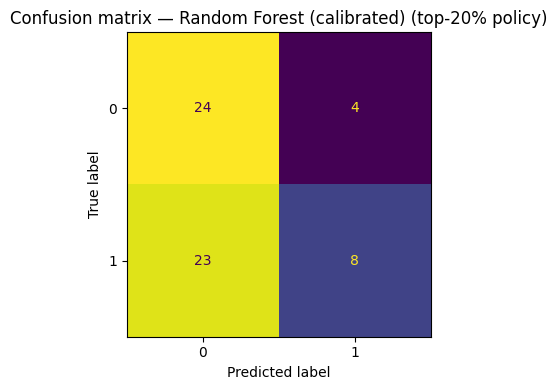

Raw confusion_matrix (tn fp; fn tp):
[[24  4]
 [23  8]]
Equivalent score cutoff (for reference only): 0.780
Top-20% capacity view — precision=0.667, recall=0.258


In [18]:
def eval_binary(y_true, y_pred, proba) -> dict:
    out = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba) if y_true.nunique() > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, proba) if y_true.nunique() > 1 else np.nan,
        "brier": brier_score_loss(y_true, proba),
    }
    return out


def topk_decision(proba: np.ndarray, contact_rate: float = 0.2) -> np.ndarray:
    """Predict churn=1 for top-k highest-risk donors only (capacity-anchored decision)."""
    n = len(proba)
    k = max(1, int(np.ceil(contact_rate * n)))
    order = np.argsort(-proba)
    pred = np.zeros(n, dtype=int)
    pred[order[:k]] = 1
    return pred


def precision_recall_at_top_rate(y_true: pd.Series, proba: np.ndarray, contact_rate: float = 0.2) -> tuple[float, float]:
    pred_k = topk_decision(proba, contact_rate=contact_rate)
    precision_k = precision_score(y_true, pred_k, zero_division=0)
    recall_k = recall_score(y_true, pred_k, zero_division=0)
    return float(precision_k), float(recall_k)


def threshold_from_topk_policy(proba: np.ndarray, contact_rate: float = 0.2) -> float:
    """Equivalent score cutoff for display only; actual prediction uses top-k ranking."""
    q = float(max(0.0, min(1.0, 1.0 - contact_rate)))
    return float(np.quantile(proba, q))

models_fit = {
    "Dummy (stratified)": make_dummy_pipeline(),
    "Logistic Regression": make_logreg_pipeline(),
    "Random Forest": make_rf_pipeline(),
}

CONTACT_RATE = 0.2
MIN_PRECISION_FOR_ACTION = 0.35

# Strict temporal walk-forward over training windows.
train_obs_sorted = np.sort(panel.loc[train_mask, "observation_as_of"].unique())
oof_probs: dict[str, pd.Series] = {
    name: pd.Series(index=X_train.index, dtype=float) for name in models_fit
}

if len(train_obs_sorted) < 2:
    print("Not enough distinct observation dates in train for walk-forward validation; skipping OOF metrics.")
else:
    for valid_as_of in train_obs_sorted[1:]:
        fold_tr_mask = panel.loc[train_mask, "observation_as_of"] < valid_as_of
        fold_va_mask = panel.loc[train_mask, "observation_as_of"] == valid_as_of

        X_tr_f = X_train.loc[fold_tr_mask]
        y_tr_f = y_train.loc[fold_tr_mask]
        X_va_f = X_train.loc[fold_va_mask]

        if y_tr_f.nunique() < 2 or len(X_va_f) == 0:
            continue

        for name, est in models_fit.items():
            fold_est = clone(est)
            fold_est.fit(X_tr_f, y_tr_f)
            oof_probs[name].loc[X_va_f.index] = fold_est.predict_proba(X_va_f)[:, 1]

oof_summary_rows = []
for name, s in oof_probs.items():
    mask = s.notna()
    if not mask.any():
        continue
    y_oof = y_train.loc[mask]
    p_oof = s.loc[mask].to_numpy()
    t_oof = threshold_from_topk_policy(p_oof, contact_rate=CONTACT_RATE)
    pred_oof = topk_decision(p_oof, contact_rate=CONTACT_RATE)
    m = eval_binary(y_oof, pred_oof, p_oof)
    p20, r20 = precision_recall_at_top_rate(y_oof, p_oof, contact_rate=CONTACT_RATE)
    m.update({"model": name, "oof_threshold": t_oof, "precision_at_capacity": p20, "recall_at_capacity": r20})
    oof_summary_rows.append(m)

if oof_summary_rows:
    oof_df = pd.DataFrame(oof_summary_rows).set_index("model").sort_values("pr_auc", ascending=False)
    print("Walk-forward OOF summary (train only; thresholding by outreach capacity):")
    display(oof_df[["oof_threshold", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier", "precision_at_capacity", "recall_at_capacity"]].round(3))

trained: dict[str, Pipeline] = {}
thresholds: dict[str, float] = {}

# Fit baseline models on full train set and keep equivalent cutoffs for reporting.
for model_name, pipe in models_fit.items():
    pipe.fit(X_train, y_train)
    trained[model_name] = pipe

    if oof_probs[model_name].notna().any():
        p_oof = oof_probs[model_name].dropna().to_numpy()
        thresholds[model_name] = threshold_from_topk_policy(
            p_oof,
            contact_rate=CONTACT_RATE,
        )
    else:
        p_train = pipe.predict_proba(X_train)[:, 1]
        thresholds[model_name] = threshold_from_topk_policy(
            p_train,
            contact_rate=CONTACT_RATE,
        )

# Calibrated primary model (RF) for better risk probability quality.
calibrated_rf = CalibratedClassifierCV(
    estimator=make_rf_pipeline(),
    method="sigmoid",
    cv=3,
)
calibrated_rf.fit(X_train, y_train)
trained["Random Forest (calibrated)"] = calibrated_rf

if oof_probs["Random Forest"].notna().any():
    p_oof_rf = oof_probs["Random Forest"].dropna().to_numpy()
    thresholds["Random Forest (calibrated)"] = threshold_from_topk_policy(
        p_oof_rf,
        contact_rate=CONTACT_RATE,
    )
else:
    p_train_cal = calibrated_rf.predict_proba(X_train)[:, 1]
    thresholds["Random Forest (calibrated)"] = threshold_from_topk_policy(
        p_train_cal,
        contact_rate=CONTACT_RATE,
    )

proba_train_primary = calibrated_rf.predict_proba(X_train)[:, 1]

test_metrics_final = []
for model_name, pipe in trained.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    t_star = thresholds[model_name]
    pred = topk_decision(proba, contact_rate=CONTACT_RATE)
    m = eval_binary(y_test, pred, proba)
    p20, r20 = precision_recall_at_top_rate(y_test, proba, contact_rate=CONTACT_RATE)
    m["model"] = model_name
    m["threshold"] = t_star
    m["precision_at_capacity"] = p20
    m["recall_at_capacity"] = r20
    test_metrics_final.append(m)

metrics_df_final = (
    pd.DataFrame(test_metrics_final)
    .set_index("model")[[
        "threshold", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier", "precision_at_capacity", "recall_at_capacity"
    ]]
    .round(3)
)
print("Held-out test (latest observation window). Thresholds selected using train OOF predictions with capacity-aware policy.")
display(metrics_df_final)

primary_model_name = "Random Forest (calibrated)"
primary = trained[primary_model_name]
t_primary = thresholds[primary_model_name]
proba_test = primary.predict_proba(X_test)[:, 1]
pred_test = topk_decision(proba_test, contact_rate=CONTACT_RATE)

print(f"\nClassification report — {primary_model_name} (test)")
print(classification_report(y_test, pred_test, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix — {primary_model_name} (top-{int(CONTACT_RATE * 100)}% policy)")
plt.tight_layout()
plt.show()

print("Raw confusion_matrix (tn fp; fn tp):")
print(confusion_matrix(y_test, pred_test))
print(f"Equivalent score cutoff (for reference only): {t_primary:.3f}")

p20_test, r20_test = precision_recall_at_top_rate(y_test, proba_test, contact_rate=CONTACT_RATE)
print(f"Top-{int(CONTACT_RATE * 100)}% capacity view — precision={p20_test:.3f}, recall={r20_test:.3f}")

## Business Insights

In [19]:
pfi = permutation_importance(
    primary,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)
pfi_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance_mean": pfi.importances_mean, "importance_std": pfi.importances_std})
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(pfi_df.head(15))

test_idx = panel.loc[test_mask].index
risk_panel = panel.loc[test_idx, ["supporter_id", "observation_as_of", "feature_cutoff", "churn", "acquisition_channel", "primary_campaign"]].copy()
risk_panel["risk_score"] = proba_test

# Dynamic tiers based on train-score percentiles (stable even if score scale drifts).
medium_cut = float(np.quantile(proba_train_primary, 0.5))
high_cut = float(np.quantile(proba_train_primary, 0.8))


def risk_tier(p: float) -> str:
    if p >= high_cut:
        return "high"
    if p >= medium_cut:
        return "medium"
    return "low"


risk_panel["risk_tier"] = risk_panel["risk_score"].apply(risk_tier)
display(risk_panel.sort_values("risk_score", ascending=False).head(20))
print("Tier counts (test window):")
print(risk_panel["risk_tier"].value_counts())

# Capacity-aware shortlist for operations.
n_contact = max(1, int(np.ceil(CONTACT_RATE * len(risk_panel))))
outreach_list = risk_panel.sort_values("risk_score", ascending=False).head(n_contact).copy()
outreach_list["rank"] = np.arange(1, len(outreach_list) + 1)
outreach_list = outreach_list[[
    "rank",
    "supporter_id",
    "risk_score",
    "risk_tier",
    "acquisition_channel",
    "primary_campaign",
    "churn",
]]

print(f"\nTop-{int(CONTACT_RATE * 100)}% outreach list (n={n_contact})")
display(outreach_list)
print("Observed churn hit-rate inside outreach list:", round(float(outreach_list["churn"].mean()), 3))

top = pfi_df.head(5)["feature"].tolist()
print("\nPlain-English drivers (from permutation importance; associative, not causal):")
blurbs = {
    "days_since_last_gift": "Longer gaps since the last gift align with higher churn risk — recency dominates many donor models.",
    "freq_90d": "Fewer gifts in the last 90 days suggests cooling engagement before the prediction window.",
    "freq_180d": "Lower six-month gift frequency captures steadier vs episodic donors.",
    "freq_trend_ratio": "A shrinking recent rate vs the prior quarter flags deceleration in giving.",
    "lifetime_value_php": "Historical generosity can correlate with both loyalty and different lapse patterns.",
    "avg_gift_php": "Average gift size helps separate high-commitment vs occasional supporters.",
    "avg_gift_90d_php": "Recent average gift size can signal upgrade or pullback behavior.",
    "has_recurring": "Recurring flags often associate with stickier relationships.",
    "campaign_diversity": "Breadth of campaigns touched may reflect engagement depth.",
    "acquisition_channel": "Some channels bring donors with different retention profiles.",
    "primary_campaign": "Dominant campaign affinity can track with cause-match and renewal cycles.",
}
for f in top:
    print(f"- **{f}**: {blurbs.get(f, 'Contributes to separating churners from renewers in this dataset.')}")

print("\nActionable retention ideas (hypothesis-generating; validate with experiments):")
print(
    "1. **Recency triggers** — auto-queue personal outreach when `days_since_last_gift` or `freq_90d` crosses team-defined thresholds.\n"
    "2. **Recurring upgrades** — prioritize nudges for one-time donors with high `freq_trend_ratio` decay (they slowed but still care).\n"
    "3. **Campaign-matched asks** — use `primary_campaign` to tailor the next appeal story.\n"
    "4. **Channel playbooks** — compare stewardship intensity by `acquisition_channel` for high `risk_score` tiers.\n"
    "5. **Test and measure** — run holdout A/B tests on outreach; model scores prioritize workload, not proof of causal lift."
)

# --- Business impact sketch (illustrative; edit assumptions for leadership decks) ---
n_targeted = len(outreach_list)
n_churners_targeted = int(outreach_list["churn"].sum())
avg_gift_train = float(panel.loc[train_mask & (panel["churn"] == 0), "avg_gift_php"].median())
if np.isnan(avg_gift_train):
    avg_gift_train = float(panel.loc[train_mask, "avg_gift_php"].median())
save_rate_if_contacted = 0.12
saved_donors = n_targeted * save_rate_if_contacted
revenue_saved = saved_donors * avg_gift_train
print("\n--- Impact sketch (editable assumptions) ---")
print(f"Donors targeted by capacity policy: {n_targeted}")
print(f"Observed churners in targeted list: {n_churners_targeted}")
print(
    f"If save-rate among targeted donors is {save_rate_if_contacted:.0%}, "
    f"~{saved_donors:.1f} donors may be retained per cycle."
)
print(
    f"Rough PHP upside (median train `avg_gift_php` ≈ {avg_gift_train:,.0f}): ~{revenue_saved:,.0f} PHP per scoring cycle "
    "(not net of program cost)."
)

,feature,importance_mean,importance_std
0,freq_prior_90d,0.053341,0.021609
1,lifetime_value_php,0.047120,0.026451
2,max_gift_php,0.026767,0.013549
3,days_since_last_gift,0.023694,0.021479
4,gift_count_positive,0.019700,0.011822
5,gift_count,0.015899,0.024600
6,freq_180d,0.008295,0.021091
7,acquisition_channel,0.001882,0.024974
8,avg_gift_90d_php,-0.004224,0.014127
9,freq_90d,-0.004877,0.008101


,supporter_id,observation_as_of,feature_cutoff,churn,acquisition_channel,primary_campaign,risk_score,risk_tier
538,49,2025-12-24,2025-09-25,0,Website,(No campaign name),0.674650,medium
546,57,2025-12-24,2025-09-25,0,SocialMedia,(No campaign name),0.673396,medium
525,36,2025-12-24,2025-09-25,1,WordOfMouth,(No campaign name),0.673367,medium
513,23,2025-12-24,2025-09-25,1,Website,(No campaign name),0.671677,medium
528,39,2025-12-24,2025-09-25,1,Event,(No campaign name),0.671162,medium
548,59,2025-12-24,2025-09-25,0,WordOfMouth,(No campaign name),0.670882,medium
540,51,2025-12-24,2025-09-25,1,WordOfMouth,(No campaign name),0.670610,medium
492,2,2025-12-24,2025-09-25,1,SocialMedia,(No campaign name),0.670111,medium
542,53,2025-12-24,2025-09-25,1,WordOfMouth,(No campaign name),0.669934,medium
495,5,2025-12-24,2025-09-25,0,Website,Year-End Hope,0.669737,medium


Tier counts (test window):
risk_tier
low       47
medium    12
Name: count, dtype: int64

Top-20% outreach list (n=12)


,rank,supporter_id,risk_score,risk_tier,acquisition_channel,primary_campaign,churn
538,1,49,0.674650,medium,Website,(No campaign name),0
546,2,57,0.673396,medium,SocialMedia,(No campaign name),0
525,3,36,0.673367,medium,WordOfMouth,(No campaign name),1
513,4,23,0.671677,medium,Website,(No campaign name),1
528,5,39,0.671162,medium,Event,(No campaign name),1
548,6,59,0.670882,medium,WordOfMouth,(No campaign name),0
540,7,51,0.670610,medium,WordOfMouth,(No campaign name),1
492,8,2,0.670111,medium,SocialMedia,(No campaign name),1
542,9,53,0.669934,medium,WordOfMouth,(No campaign name),1
495,10,5,0.669737,medium,Website,Year-End Hope,0


Observed churn hit-rate inside outreach list: 0.667

Plain-English drivers (from permutation importance; associative, not causal):
- **freq_prior_90d**: Contributes to separating churners from renewers in this dataset.
- **lifetime_value_php**: Historical generosity can correlate with both loyalty and different lapse patterns.
- **max_gift_php**: Contributes to separating churners from renewers in this dataset.
- **days_since_last_gift**: Longer gaps since the last gift align with higher churn risk — recency dominates many donor models.
- **gift_count_positive**: Contributes to separating churners from renewers in this dataset.

Actionable retention ideas (hypothesis-generating; validate with experiments):
1. **Recency triggers** — auto-queue personal outreach when `days_since_last_gift` or `freq_90d` crosses team-defined thresholds.
2. **Recurring upgrades** — prioritize nudges for one-time donors with high `freq_trend_ratio` decay (they slowed but still care).
3. **Campaign-matched a

## Limitations

- **Correlation ≠ causation.** Feature importance and churn associations **do not prove** that changing a lever (e.g., email frequency) will reduce churn; run controlled tests for that.
- **Small, static extract.** Row counts are modest; estimates will be **volatile**. Refresh scores as new gifts arrive and monitor drift.
- **Label definition.** Churn here is **no positive PHP gift in the 90-day outcome window**; time/volunteer-only activity is excluded by design (`value_php`).
- **Bias and coverage.** Supporters without digital trails or with irregular offline gifts may be mis-scored; acquisition channels and campaigns can encode historical marketing bias.
- **Single-organization fit.** Coefficients and thresholds should be **recalibrated** before use elsewhere.

---

**Related:** exploratory donor analytics (channels, allocations, social) remain in `Donor_Analysis.ipynb`.